In [29]:
import matplotlib.pyplot as plt
import re
import itertools

In [37]:
EXPERIMENT_NAME = "KEDA Prometheus"

def parse_replicas(file_path : str) -> list[int]:
    replicas = []
    with (open(f"{file_path}/watch.log")) as f:
        for line in f:
            parts = line.split()
            if parts[0] == "keda-hpa-webserver-scaledobject":
                replicas.append(int(parts[6]))
    return replicas

def plot_replicas(file_path : str) -> None:
    replicas = parse_replicas(file_path)
    plt.plot(replicas, color="red", label=EXPERIMENT_NAME)
    plt.ylabel("Replica Count") 
    plt.legend()
    plt.tight_layout()
    plt.show()

def parse_p99(file_path : str) -> list[float]:
    latencies = []
    files = [f"{file_path}/vegeta.1.log", f"{file_path}/vegeta.2.log", f"{file_path}/vegeta.3.log"]
    lines = itertools.chain.from_iterable(open(f) for f in files)
    for line in lines:
        if line.strip().startswith("Latencies"):
            # format: [mean, 50, 95, 99, max]
            vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
            p99 = vals[3]
            if p99.endswith("ms"):
                latencies.append(float(p99[:-2]) / 1000)
            elif p99.endswith("µs"):
                latencies.append(float(p99[:-2]) / 1e6)
            elif p99.endswith("ns"):
                latencies.append(float(p99[:-2]) / 1e9)
            else:
                latencies.append(float(p99[:-1]))
    return latencies
    
def plot_p99(file_path : str) -> None:
    latencies = parse_p99(file_path)   
    plt.plot(latencies, color="red", label=EXPERIMENT_NAME)
    plt.ylabel("P99 Latency (s)") 
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plot(file_path : str) -> None:
    replicas = parse_replicas(file_path)
    latencies = parse_p99(file_path)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas", color="tab:blue")
    ax1.plot(replicas, color="tab:blue", label="Replicas")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(range(0, len(replicas), 60))

    ax2 = ax1.twinx()
    ax2.set_ylabel("P99 Latency (s)", color="tab:red")
    ax2.plot(latencies, color="tab:red", label="P99 Latency")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Replicas vs P99")
    fig.tight_layout()
    fig.show()

/tmp/ipykernel_36341/2308390732.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


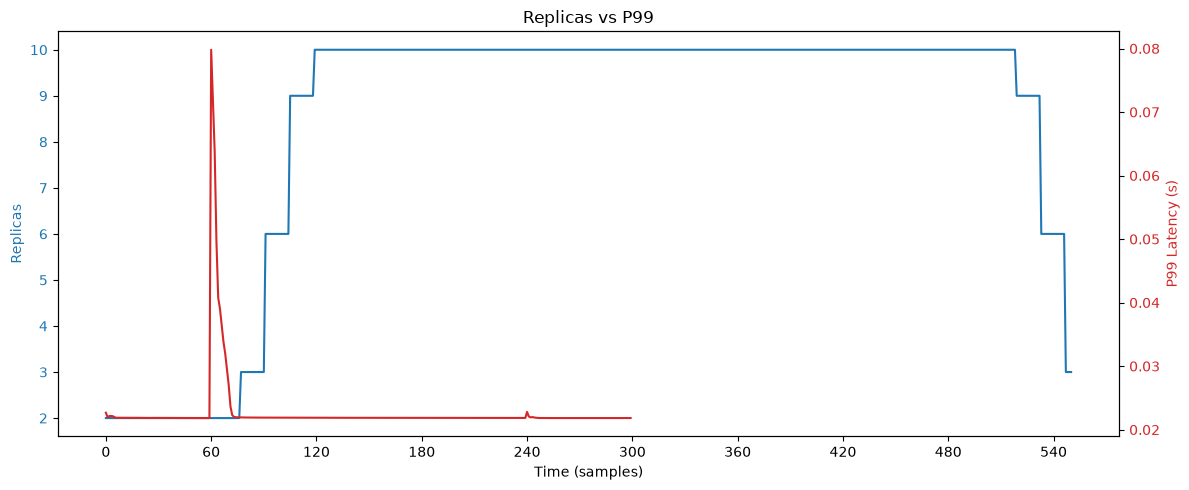

In [38]:
plot("../results/keda_prometheus/experiment_run_1")